In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import optuna
import shap
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, f1_score, average_precision_score, precision_score, recall_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
from category_encoders import TargetEncoder

In [2]:
train = pd.read_csv("../data/fraudTrain.csv")
test = pd.read_csv("../data/fraudTest.csv")

In [3]:
drop_cols = ['Unnamed: 0', 'lat', 'long', 'merch_lat', 'merch_long', 'first','last','street','zip','dob','trans_num','unix_time']
train.drop(columns=drop_cols, inplace=True)
test.drop(columns=drop_cols, inplace=True)

In [4]:
print("Train Shape:", train.shape)
print("Test Shape :", test.shape)
print("\nTarget Distribution")
print(train['is_fraud'].value_counts())
print(train['is_fraud'].value_counts(normalize=True))
print("\nMissing Values")
print(train.isnull().sum().sum())
print(test.isnull().sum().sum())
print("\nDuplicates")
print("Train:",train.duplicated().sum())
print("Test :",test.duplicated().sum())

Train Shape: (1296675, 11)
Test Shape : (555719, 11)

Target Distribution
is_fraud
0    1289169
1       7506
Name: count, dtype: int64
is_fraud
0    0.994211
1    0.005789
Name: proportion, dtype: float64

Missing Values
0
0

Duplicates
Train: 0
Test : 0


In [5]:
train.head(2)

,trans_date_trans_time,cc_num,merchant,category,amt,gender,city,state,city_pop,job,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,Moravian Falls,NC,3495,"Psychologist, counselling",0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,Orient,WA,149,Special educational needs teacher,0


In [6]:
def feature_engineering(df):
    df = df.copy()
    df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
    df['hour'] = (df['trans_date_trans_time'].dt.hour)
    df['day_of_week'] = (df['trans_date_trans_time'].dt.dayofweek)
    df['month'] = (df['trans_date_trans_time'].dt.month)
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    df['is_night'] = (((df['hour'] < 6) | (df['hour'] > 22))).astype(int)
    df['amt_log'] = np.log1p(df['amt'])
    return df

train = feature_engineering(train)
test = feature_engineering(test)

user_mean = (train.groupby('cc_num')['amt'].mean())
user_std = (train.groupby('cc_num')['amt'].std())
train['avg_amt_user'] = (train['cc_num'].map(user_mean))
test['avg_amt_user'] = (test['cc_num'].map(user_mean))
train['std_amt_user'] = (train['cc_num'].map(user_std))
test['std_amt_user'] = (test['cc_num'].map(user_std))
global_mean_amt = train['amt'].mean()
train['avg_amt_user'] = (train['avg_amt_user'].fillna(global_mean_amt))
test['avg_amt_user'] = (test['avg_amt_user'].fillna(global_mean_amt))
train['std_amt_user'] = (train['std_amt_user'].fillna(0))
test['std_amt_user'] = (test['std_amt_user'].fillna(0))
train['amt_to_mean'] = (train['amt'] /(train['avg_amt_user'] + 1))
test['amt_to_mean'] = (test['amt'] / (test['avg_amt_user'] + 1))

In [7]:
X_train = train.drop(columns='is_fraud')
y_train =  train['is_fraud']
X_test = test.drop(columns='is_fraud')
y_test = test['is_fraud']

In [8]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)
print("List of Columns:", X_train.columns)

X_train: (1296675, 19)
y_train: (1296675,)
X_test : (555719, 19)
y_test : (555719,)
List of Columns: Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'gender', 'city', 'state', 'city_pop', 'job', 'hour', 'day_of_week',
       'month', 'is_weekend', 'is_night', 'amt_log', 'avg_amt_user',
       'std_amt_user', 'amt_to_mean'],
      dtype='object')


In [9]:
cat_cols = ['merchant', 'category', 'job', 'state', 'city']
gen_cols = ['gender']
num_median = ['amt', 'amt_log', 'avg_amt_user','amt_to_mean', 'city_pop']
num_constant_zero = ['std_amt_user']
num_time = ['hour','day_of_week','month']
num_binary = ['is_night','is_weekend']

In [10]:
median_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
constant_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', StandardScaler())
])
time_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
binary_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('target_enc', TargetEncoder(smoothing=10))
])
gen_pipe = Pipeline([
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer([
    ('median', median_pipe, num_median),
    ('constant', constant_pipe, num_constant_zero),
    ('time', time_pipe, num_time),
    ('binary', binary_pipe, num_binary),
    ('cat', cat_pipe, cat_cols),
    ('gen', gen_pipe, gen_cols)
], sparse_threshold=0)

In [11]:
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int( "min_child_weight",1,10),        
        "reg_alpha":trial.suggest_float("reg_alpha",0,5),
        "reg_lambda":trial.suggest_float("reg_lambda",0,5),
        "scale_pos_weight": scale_pos_weight,
        "eval_metric": "logloss",
        "random_state":42,
        "n_jobs":-1
    }
    model = XGBClassifier(**params)
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    score =cross_val_score(pipe, X_train, y_train, cv=cv, scoring='average_precision').mean() 
    return score
study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(objective_xgb, n_trials=50)
best_xgb = XGBClassifier(**study_xgb.best_params, eval_metric='logloss', scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1)
print(best_xgb)

[I 2026-05-13 16:59:03,442] A new study created in memory with name: no-name-9df32b77-1fa1-44ee-8123-b6f14fe09f2d
[I 2026-05-13 17:00:10,480] Trial 0 finished with value: 0.730231427969729 and parameters: {'n_estimators': 441, 'max_depth': 3, 'learning_rate': 0.029170652431201705, 'subsample': 0.8656487445218383, 'colsample_bytree': 0.8172879782844943, 'min_child_weight': 1, 'reg_alpha': 1.695377426262263, 'reg_lambda': 0.9620498509580927}. Best is trial 0 with value: 0.730231427969729.
[I 2026-05-13 17:00:59,516] Trial 1 finished with value: 0.7880732036299758 and parameters: {'n_estimators': 249, 'max_depth': 4, 'learning_rate': 0.04124637560800045, 'subsample': 0.9625504749350118, 'colsample_bytree': 0.6848288546315034, 'min_child_weight': 1, 'reg_alpha': 0.5917112737521596, 'reg_lambda': 0.3632407422532463}. Best is trial 1 with value: 0.7880732036299758.
[I 2026-05-13 17:01:54,732] Trial 2 finished with value: 0.9070997156849594 and parameters: {'n_estimators': 251, 'max_depth': 6

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9755776553892367, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.09813538432188634,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=493, n_jobs=-1,
              num_parallel_tree=None, ...)


In [12]:
def objective_lgbm(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "num_leaves": trial.suggest_int("num_leaves", 20, 80),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "class_weight": "balanced",
        "min_child_samples":trial.suggest_int("min_child_samples",5,50),
        "subsample":trial.suggest_float("subsample",0.6,1.0),
        "colsample_bytree":trial.suggest_float("colsample_bytree",0.6,1.0),
        "reg_alpha":trial.suggest_float("reg_alpha",0,5),
        "reg_lambda":trial.suggest_float("reg_lambda",0,5),
        "random_state":42,
        "verbosity": -1,
        "n_jobs": -1
    }
    model = LGBMClassifier(**params)
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    score= cross_val_score(pipe, X_train, y_train, cv=cv, scoring='average_precision').mean()
    return score
study_lgbm = optuna.create_study(direction="maximize")
study_lgbm.optimize(objective_lgbm, n_trials=50)
best_lgbm = LGBMClassifier(**study_lgbm.best_params, class_weight='balanced', random_state=42, verbosity=-1, n_jobs=-1)
print(best_lgbm)

[I 2026-05-13 18:02:31,570] A new study created in memory with name: no-name-e2158b88-c4ce-4f35-b798-a1ebb3b9a468
[I 2026-05-13 18:03:49,019] Trial 0 finished with value: 0.9327395629230714 and parameters: {'n_estimators': 397, 'learning_rate': 0.09400195725899754, 'num_leaves': 75, 'max_depth': 7, 'min_child_samples': 8, 'subsample': 0.9910854459831001, 'colsample_bytree': 0.615616233035407, 'reg_alpha': 4.321145276914294, 'reg_lambda': 1.3000614195442668}. Best is trial 0 with value: 0.9327395629230714.
[I 2026-05-13 18:04:22,327] Trial 1 finished with value: 0.6591282981393418 and parameters: {'n_estimators': 149, 'learning_rate': 0.030649658518025646, 'num_leaves': 58, 'max_depth': 3, 'min_child_samples': 30, 'subsample': 0.8879838329992822, 'colsample_bytree': 0.9147460871908759, 'reg_alpha': 3.0352617352304936, 'reg_lambda': 4.151479159547828}. Best is trial 0 with value: 0.9327395629230714.
[I 2026-05-13 18:05:26,641] Trial 2 finished with value: 0.9044943606097324 and parameter

LGBMClassifier(class_weight='balanced', colsample_bytree=0.9580033966997605,
               learning_rate=0.09653608664246219, max_depth=8, n_estimators=500,
               n_jobs=-1, num_leaves=69, random_state=42,
               reg_alpha=4.227178840723487, reg_lambda=4.829173913052239,
               subsample=0.6423629430698251, verbosity=-1)


In [ ]:
# rf = RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=2, class_weight='balanced', random_state=42, n_jobs=-1)

In [14]:
def objective_rf(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "max_depth": trial.suggest_int("max_depth", 5, 30),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "max_features": trial.suggest_categorical("max_features",["sqrt", "log2"]),
        "bootstrap": trial.suggest_categorical("bootstrap",[True, False]),
        "class_weight": trial.suggest_categorical("class_weight",["balanced", "balanced_subsample"]),
        "criterion": trial.suggest_categorical("criterion",["gini", "entropy", "log_loss"]),
        "random_state": 42,
        "n_jobs": -1
    }
    model = RandomForestClassifier(**params)
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    score= cross_val_score(pipe, X_train, y_train, cv=cv, scoring='average_precision').mean()
    return score
study_rf = optuna.create_study(direction="maximize")
study_rf.optimize(objective_rf, n_trials=5)
best_rf = RandomForestClassifier(**study_rf.best_params, random_state=42, n_jobs=-1)
print(best_rf)

[I 2026-05-13 19:45:29,048] A new study created in memory with name: no-name-ba4c669b-db13-4605-a60d-7f6910a3e97b
[I 2026-05-13 19:59:05,455] Trial 0 finished with value: 0.8137836388312462 and parameters: {'n_estimators': 530, 'max_depth': 9, 'min_samples_leaf': 3, 'min_samples_split': 16, 'max_features': 'log2', 'bootstrap': True, 'class_weight': 'balanced_subsample', 'criterion': 'log_loss'}. Best is trial 0 with value: 0.8137836388312462.
[I 2026-05-13 20:50:02,445] Trial 1 finished with value: 0.8419984772832082 and parameters: {'n_estimators': 933, 'max_depth': 12, 'min_samples_leaf': 5, 'min_samples_split': 5, 'max_features': 'sqrt', 'bootstrap': True, 'class_weight': 'balanced_subsample', 'criterion': 'entropy'}. Best is trial 1 with value: 0.8419984772832082.
[I 2026-05-13 21:01:14,012] Trial 2 finished with value: 0.7325871236964144 and parameters: {'n_estimators': 533, 'max_depth': 6, 'min_samples_leaf': 3, 'min_samples_split': 2, 'max_features': 'sqrt', 'bootstrap': True, '

RandomForestClassifier(class_weight='balanced', max_depth=29,
                       min_samples_leaf=5, min_samples_split=16,
                       n_estimators=923, n_jobs=-1, random_state=42)


In [15]:
metrics_summary = {}
models = {
    "RF": best_rf,
    "XGB": best_xgb,
    "LGBM": best_lgbm
}
results = {}
trained_pipelines={}
for name, model in models.items():
    # WITHOUT SMOTE
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    prob = pipe.predict_proba(X_test)[:, 1]
    pred = pipe.predict(X_test)
    results[name + "_NO_SMOTE"] = prob
    trained_pipelines[name + "_NO_SMOTE"] = pipe
    roc = roc_auc_score(y_test, prob)
    pr = average_precision_score(y_test, prob)
    f1 = f1_score(y_test, pred)
    precision_score_val = precision_score(y_test, pred)
    recall_score_val = recall_score(y_test, pred)
    metrics_summary[name + "_NO_SMOTE"] = {
        "ROC": roc,
        "PR_AUC": pr,
        "F1": f1,
        "Precision": precision_score_val,
        "Recall": recall_score_val
    }
    print(f"\n{name} WITHOUT SMOTE")
    print("ROC AUC:", roc)
    print("PR AUC :", pr)
    print("F1:", f1)
    print("Precision:", precision_score_val)
    print("Recall:", recall_score_val)
    print(classification_report(y_test, pred))
    
    # WITH SMOTE
    pipe_smote = ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(sampling_strategy=0.3, random_state=42)),
        ('model', model)
    ])
    pipe_smote.fit(X_train, y_train)
    prob_smote = pipe_smote.predict_proba(X_test)[:, 1]
    pred_smote = pipe_smote.predict(X_test)
    results[name + "_SMOTE"] = prob_smote
    trained_pipelines[name + "_SMOTE"] = pipe_smote
    roc = roc_auc_score(y_test, prob_smote)
    pr = average_precision_score(y_test, prob_smote)
    f1 = f1_score(y_test, pred_smote)
    precision_score_val = precision_score(y_test, pred_smote)
    recall_score_val = recall_score(y_test, pred_smote)
    metrics_summary[name] = {
        "ROC": roc,
        "PR_AUC": pr,
        "F1": f1,
        "Precision": precision_score_val,
        "Recall": recall_score_val
    }
    print(f"\n{name} WITH SMOTE")

    print("ROC AUC:", roc)
    print("PR AUC :", pr)
    print("F1:", f1)
    print("Precision:", precision_score_val)
    print("Recall:", recall_score_val)
    print(classification_report(y_test, pred_smote))
    trained_pipelines[name + "_SMOTE"] = pipe_smote


RF WITHOUT SMOTE
ROC AUC: 0.9596795169289541
PR AUC : 0.167447572911149
F1: 0.18188129121832697
Precision: 0.35597826086956524
Recall: 0.12214452214452215
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.36      0.12      0.18      2145

    accuracy                           1.00    555719
   macro avg       0.68      0.56      0.59    555719
weighted avg       0.99      1.00      0.99    555719



C:\Users\adity\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\adity\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\adity\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\adity\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^


RF WITH SMOTE
ROC AUC: 0.9551866606202613
PR AUC : 0.12783835846729086
F1: 0.1605331787887569
Precision: 0.2120980091883614
Recall: 0.12913752913752913
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.21      0.13      0.16      2145

    accuracy                           0.99    555719
   macro avg       0.60      0.56      0.58    555719
weighted avg       0.99      0.99      0.99    555719


XGB WITHOUT SMOTE
ROC AUC: 0.9234516088768636
PR AUC : 0.28256810235600976
F1: 0.24619457313037724
Precision: 0.4241733181299886
Recall: 0.17342657342657342
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.42      0.17      0.25      2145

    accuracy                           1.00    555719
   macro avg       0.71      0.59      0.62    555719
weighted avg       0.99      1.00      1.00    555719


XGB WITH SMOTE
ROC AUC: 0.91438236

In [20]:
print(metrics_summary.items())

dict_items([('RF_NO_SMOTE', {'ROC': np.float64(0.9596795169289541), 'PR_AUC': np.float64(0.167447572911149), 'F1': np.float64(0.18188129121832697), 'Precision': np.float64(0.35597826086956524), 'Recall': np.float64(0.12214452214452215)}), ('RF', {'ROC': np.float64(0.9551866606202613), 'PR_AUC': np.float64(0.12783835846729086), 'F1': np.float64(0.1605331787887569), 'Precision': np.float64(0.2120980091883614), 'Recall': np.float64(0.12913752913752913)}), ('XGB_NO_SMOTE', {'ROC': np.float64(0.9234516088768636), 'PR_AUC': np.float64(0.28256810235600976), 'F1': np.float64(0.24619457313037724), 'Precision': np.float64(0.4241733181299886), 'Recall': np.float64(0.17342657342657342)}), ('XGB', {'ROC': np.float64(0.9143823606824037), 'PR_AUC': np.float64(0.25736726098144275), 'F1': np.float64(0.2977435332966428), 'Precision': np.float64(0.3633310946944258), 'Recall': np.float64(0.2522144522144522)}), ('LGBM_NO_SMOTE', {'ROC': np.float64(0.9276467031278495), 'PR_AUC': np.float64(0.265589414401400

In [21]:
best_name = max(
    metrics_summary,
    key=lambda k: metrics_summary[k]["PR_AUC"]
)

print(f"\nBEST MODEL: {best_name}")

# fix old naming issue
if best_name in ["RF", "XGB", "LGBM"]:
    result_key = best_name + "_SMOTE"
else:
    result_key = best_name

best_probs = results[result_key]

best_pipeline = trained_pipelines[result_key]

print(metrics_summary[best_name])


BEST MODEL: LGBM
{'ROC': np.float64(0.9434786982825728), 'PR_AUC': np.float64(0.35092746199005714), 'F1': np.float64(0.306830122591944), 'Precision': np.float64(0.6169014084507042), 'Recall': np.float64(0.2041958041958042)}


In [24]:
preprocessor.fit(X_train, y_train)
X_train_dl = preprocessor.transform(X_train)
X_test_dl = preprocessor.transform(X_test)
if hasattr(X_train_dl, "toarray"):
    X_train_dl = X_train_dl.toarray()
if hasattr(X_test_dl, "toarray"):
    X_test_dl = X_test_dl.toarray()
X_train_ann, X_val_ann, y_train_ann, y_val_ann = train_test_split(X_train_dl, y_train, test_size=0.2,stratify=y_train, random_state=42)
weight = compute_class_weight(class_weight='balanced',classes=np.unique(y_train_ann),y=y_train_ann)
class_weight = {0: weight[0], 1: weight[1]}

def objective_ann(trial):
    units = trial.suggest_int("units", 64, 512)
    dropout = trial.suggest_float("dropout", 0.2, 0.5)
    model = Sequential([
        tf.keras.Input(shape=(X_train_dl.shape[1],)),
        Dense(units, activation='relu'),
        BatchNormalization(),
        Dropout(dropout),
        Dense(units//2, activation='relu'),
        BatchNormalization(),
        Dropout(dropout),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy')
    early_stop = EarlyStopping(monitor = 'val_loss', restore_best_weights=True, patience=3)
    model.fit(X_train_ann, y_train_ann, epochs=20, batch_size=256, verbose=0, class_weight=class_weight, validation_data=(X_val_ann, y_val_ann), 
             callbacks=[early_stop])
    preds = model.predict(X_val_ann, verbose=0).flatten()
    return average_precision_score(y_val_ann, preds)

study_ann = optuna.create_study(direction="maximize")
study_ann.optimize(objective_ann, n_trials=20)
best_params_ann = study_ann.best_params
print("Best Parameter: ", best_params_ann)

[I 2026-05-13 23:36:42,774] A new study created in memory with name: no-name-8818e40c-f474-4836-87aa-e94e0d47fe00
[I 2026-05-13 23:41:53,628] Trial 0 finished with value: 0.5418253441875547 and parameters: {'units': 192, 'dropout': 0.4361741485674464}. Best is trial 0 with value: 0.5418253441875547.
[I 2026-05-13 23:48:13,865] Trial 1 finished with value: 0.5940022499952913 and parameters: {'units': 120, 'dropout': 0.34313324376493637}. Best is trial 1 with value: 0.5940022499952913.
[I 2026-05-13 23:56:15,801] Trial 2 finished with value: 0.5848576317854435 and parameters: {'units': 314, 'dropout': 0.40273084799495185}. Best is trial 1 with value: 0.5940022499952913.
[I 2026-05-14 00:02:39,950] Trial 3 finished with value: 0.5263179857954904 and parameters: {'units': 192, 'dropout': 0.33740810349071326}. Best is trial 1 with value: 0.5940022499952913.
[I 2026-05-14 00:14:03,841] Trial 4 finished with value: 0.5929503001971334 and parameters: {'units': 307, 'dropout': 0.498032297909731

Best Parameter:  {'units': 505, 'dropout': 0.26116772442157066}


In [25]:
def build_ann(units, dropout):
    model = Sequential([
        tf.keras.Input(shape=(X_train_dl.shape[1],)),
        Dense(units, activation='relu'),
        BatchNormalization(),
        Dropout(dropout),
        Dense(units//2, activation='relu'),
        BatchNormalization(),
        Dropout(dropout),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics =['AUC'])
    return model

# WITHOUT SMOTE
weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = {0:weights[0],1:weights[1]}
early_stop = EarlyStopping(monitor = 'val_loss', restore_best_weights=True, patience=3)
ann_no = build_ann(**best_params_ann)
ann_no.fit(X_train_dl, y_train, epochs=10, batch_size=256, class_weight=class_weights, validation_split=0.2, verbose = 0, callbacks=[early_stop])
ann_no_prob = ann_no.predict(X_test_dl, verbose=0).flatten()
ann_no_pred = (ann_no_prob > 0.5).astype(int)
print("\nANN WITHOUT SMOTE")
print("ROC AUC:",roc_auc_score(y_test, ann_no_prob))
print("PR AUC:",average_precision_score(y_test, ann_no_prob))
print("F1:",f1_score(y_test,ann_no_pred))
print(classification_report(y_test, ann_no_pred))
results["ANN_NO_SMOTE"] = ann_no_prob
metrics_summary["ANN_NO_SMOTE"] = {
    "ROC":roc_auc_score(y_test,ann_no_prob),
    "PR_AUC":average_precision_score(y_test,ann_no_prob),
    "F1":f1_score(y_test,ann_no_pred),
    "Precision":precision_score(y_test,ann_no_pred,zero_division=0),
    "Recall":recall_score(y_test,ann_no_pred,zero_division=0)
}
trained_pipelines["ANN_NO_SMOTE"] = ann_no

# WITH SMOTE
sm = SMOTE(sampling_strategy=0.3,random_state=42)
X_sm, y_sm = sm.fit_resample(X_train_dl, y_train)
ann_sm = build_ann(**best_params_ann)
ann_sm.fit(X_sm, y_sm, epochs=10, batch_size=256, validation_split=0.2, verbose = 0, callbacks=[early_stop])
ann_sm_prob = ann_sm.predict(X_test_dl, verbose=0).flatten()
ann_sm_pred = (ann_sm_prob > 0.5).astype(int)
print("\nANN WITH SMOTE")
print("ROC AUC:",roc_auc_score(y_test,ann_sm_prob))
print("PR AUC:",average_precision_score(y_test,ann_sm_prob))
print("F1:",f1_score(y_test,ann_sm_pred))
print(classification_report(y_test,ann_sm_pred,zero_division=0))
results["ANN_SMOTE"] = ann_sm_prob

metrics_summary["ANN_SMOTE"] = {
    "ROC":roc_auc_score(y_test,ann_sm_prob),
    "PR_AUC":average_precision_score(y_test,ann_sm_prob),
    "F1":f1_score(y_test,ann_sm_pred),
    "Precision":precision_score(y_test,ann_sm_pred,zero_division=0),
    "Recall":recall_score(y_test,ann_sm_pred,zero_division=0)
}
trained_pipelines["ANN_SMOTE"] = ann_sm


ANN WITHOUT SMOTE
ROC AUC: 0.9695033434063808
PR AUC: 0.2932674990433438
F1: 0.11743513573302151
              precision    recall  f1-score   support

           0       1.00      0.95      0.97    553574
           1       0.06      0.87      0.12      2145

    accuracy                           0.95    555719
   macro avg       0.53      0.91      0.55    555719
weighted avg       1.00      0.95      0.97    555719


ANN WITH SMOTE
ROC AUC: 0.9639625820172595
PR AUC: 0.5473893858863749
F1: 0.5277837373954087
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.49      0.57      0.53      2145

    accuracy                           1.00    555719
   macro avg       0.74      0.79      0.76    555719
weighted avg       1.00      1.00      1.00    555719



In [26]:
precision, recall, thresholds = precision_recall_curve(y_test,best_probs)
precision = precision[:-1]
recall = recall[:-1]
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]
y_pred = (best_probs > best_thresh).astype(int)
final_threshold = best_thresh
final_predictions = y_pred
print("\nFINAL ML RESULT")
print("Best Model:", best_name)
print("Best Threshold:", best_thresh)
print(classification_report(y_test, y_pred, zero_division=0))
print("ROC AUC:",roc_auc_score(y_test, best_probs))
print("PR AUC:",average_precision_score(y_test, best_probs))
print("F1:",f1_score(y_test, y_pred))


FINAL ML RESULT
Best Model: LGBM
Best Threshold: 0.15233354176440342
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.42      0.37      0.39      2145

    accuracy                           1.00    555719
   macro avg       0.71      0.69      0.70    555719
weighted avg       1.00      1.00      1.00    555719

ROC AUC: 0.9434786982825728
PR AUC: 0.35092746199005714
F1: 0.39402107326635627


In [31]:
dl_prob = ann_no.predict(X_test_dl, verbose=0).flatten()
final_prob = (0.7*best_probs+0.3*dl_prob)
precision, recall, thresholds = precision_recall_curve(y_test,final_prob)
precision = precision[:-1]
recall = recall[:-1]
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_idx = np.argmax(f1_scores)
ensemble_thresh = thresholds[best_idx]
final_pred = (final_prob > ensemble_thresh).astype(int)
print("\nENSEMBLE RESULT")
print("Threshold:", ensemble_thresh)
print(classification_report(y_test, final_pred))
print("ROC:", roc_auc_score(y_test, final_prob))
print("PR AUC:",average_precision_score(y_test, final_prob))
print("F1:",f1_score(y_test, final_pred))

dl_prob_sm = ann_sm.predict(X_test_dl).flatten()
final_prob_sm = (0.7*best_probs+0.3*dl_prob_sm)
precision, recall, thresholds = precision_recall_curve(y_test,final_prob_sm)
precision = precision[:-1]
recall = recall[:-1]
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_idx = np.argmax(f1_scores)
ensemble_thresh_sm = thresholds[best_idx]
final_pred_sm = (final_prob_sm > ensemble_thresh_sm).astype(int)
print("\nENSEMBLE + SMOTE RESULT")
print("Threshold:", ensemble_thresh_sm)
print(classification_report(y_test, final_pred_sm))
print("ROC:", roc_auc_score(y_test, final_prob_sm))
print("PR AUC:",average_precision_score(y_test, final_prob_sm))
print("F1:",f1_score(y_test, final_pred_sm))
ensemble_results = {
    "ENSEMBLE_NO_SMOTE": {
        "prob":final_prob,
        "pred":final_pred,
        "threshold":ensemble_thresh,
        "f1":f1_score(y_test,final_pred),
        "roc":roc_auc_score(y_test,final_prob),
        "pr_auc":average_precision_score(y_test,final_prob)
    },
    "ENSEMBLE_SMOTE": {
        "prob":final_prob_sm,
        "pred":final_pred_sm,
        "threshold":ensemble_thresh_sm,
        "f1":f1_score(y_test,final_pred_sm),
        "roc":roc_auc_score(y_test,final_prob_sm),
        "pr_auc":average_precision_score(y_test,final_prob_sm)
    }
}
best_ensemble = max(ensemble_results, key=lambda k:ensemble_results[k]["f1"])
print("\nBEST ENSEMBLE:",best_ensemble)
final_probabilities = ensemble_results[best_ensemble]["prob"]
final_predictions = ensemble_results[best_ensemble]["pred"]
final_threshold = ensemble_results[best_ensemble]["threshold"]
print("\nFINAL THRESHOLD:",final_threshold)
print("\nFINAL F1:",ensemble_results[best_ensemble]["f1"])
print("\nFINAL ROC:",ensemble_results[best_ensemble]["roc"])
print("\nFINAL PR AUC:",ensemble_results[best_ensemble]["pr_auc"])
best_ensemble = max(ensemble_results,key=lambda k:ensemble_results[k]["f1"])
print("\nBEST ENSEMBLE:",best_ensemble)
final_probabilities = ensemble_results[best_ensemble]["prob"]
final_predictions = ensemble_results[best_ensemble]["pred"]
final_threshold = ensemble_results[best_ensemble]["threshold"]
print("\nFINAL THRESHOLD:",final_threshold)
print("\nFINAL F1:",ensemble_results[best_ensemble]["f1"])
print("\nFINAL ROC:",ensemble_results[best_ensemble]["roc"])
print("\nFINAL PR AUC:",ensemble_results[best_ensemble]["pr_auc"])


ENSEMBLE RESULT
Threshold: 0.3010217194512107
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.45      0.57      0.50      2145

    accuracy                           1.00    555719
   macro avg       0.72      0.79      0.75    555719
weighted avg       1.00      1.00      1.00    555719

ROC: 0.9737852959951542
PR AUC: 0.4681472788081269
F1: 0.5048106448311157
17367/17367 ━━━━━━━━━━━━━━━━━━━━ 27s 2ms/step

ENSEMBLE + SMOTE RESULT
Threshold: 0.2342872697986702
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.58      0.61      0.59      2145

    accuracy                           1.00    555719
   macro avg       0.79      0.80      0.79    555719
weighted avg       1.00      1.00      1.00    555719

ROC: 0.97657029077327
PR AUC: 0.5302987660055709
F1: 0.5905887701750397

BEST ENSEMBLE: ENSEMBLE_SMOTE

FINAL THRESHOLD: 0.2

C:\Users\adity\anaconda3\Lib\site-packages\shap\explainers\_tree.py:263: FutureWarning: In the future, passing feature_perturbation='interventional' without providing a background dataset will raise an error. Please provide a background dataset to continue using the interventional approach or set feature_perturbation='auto' to automatically switch approaches.
  warnings.warn(
C:\Users\adity\anaconda3\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


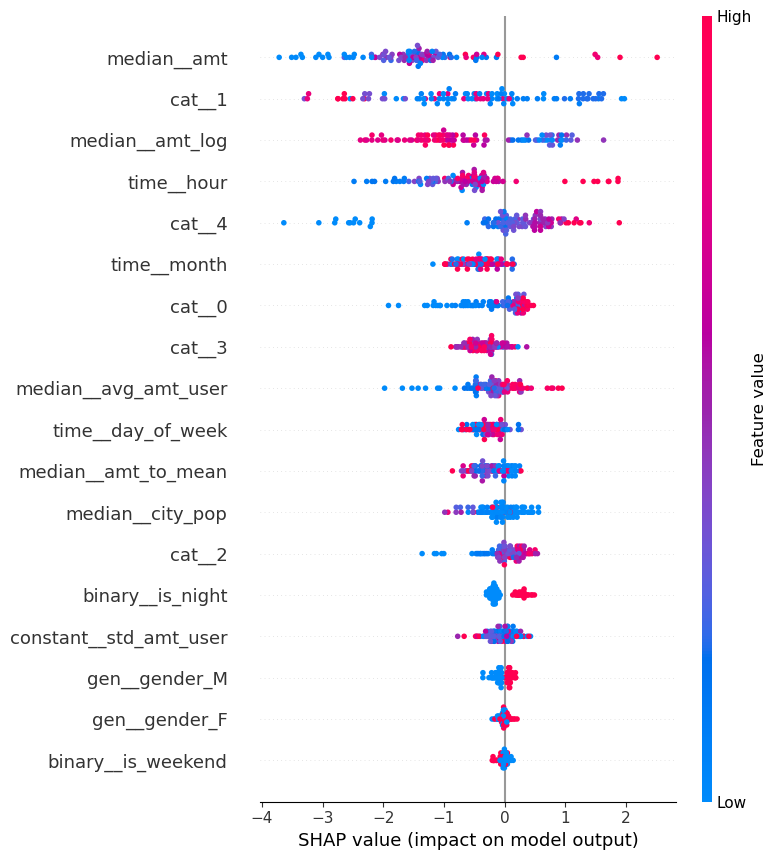

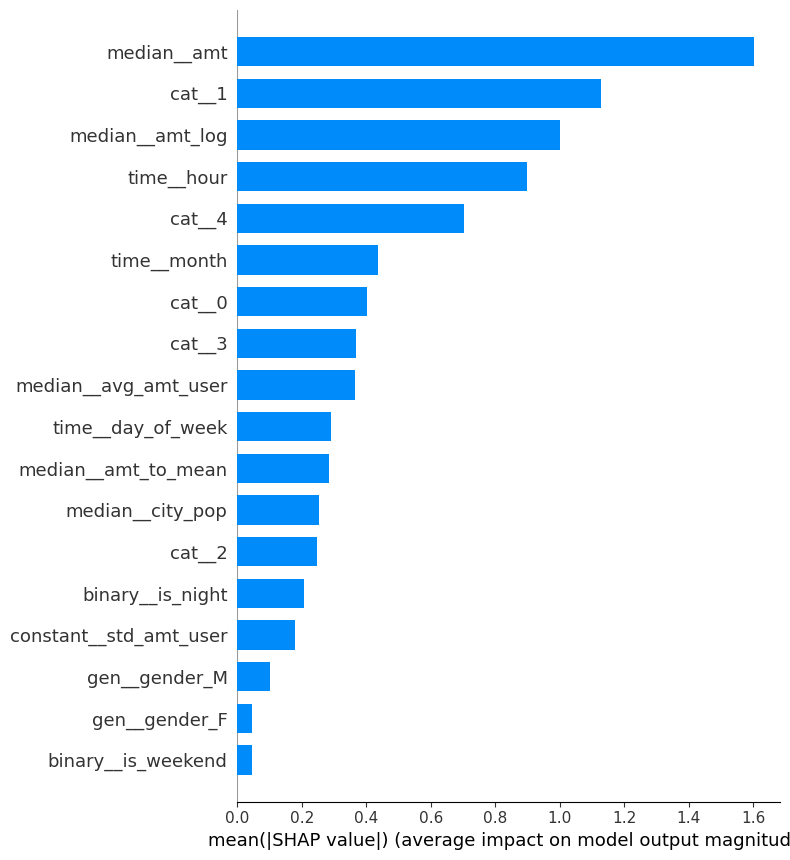

<function matplotlib.pyplot.show(close=None, block=None)>

In [28]:
base_model_name = best_name.split("_")[0]
pipe_smote = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(sampling_strategy=0.3, random_state=42)),
    ('model', models[base_model_name])
])
pipe_smote.fit(X_train, y_train)
X_sample_raw_sm = X_test.sample(100, random_state=42)
X_sample_sm = pipe_smote.named_steps['preprocessor'].transform(X_sample_raw_sm)
if hasattr(X_sample_sm, "toarray"):
    X_sample_sm = X_sample_sm.toarray()
X_sample_sm = X_sample_sm.astype(float)
try:
    feature_names_sm = (pipe_smote.named_steps['preprocessor'].get_feature_names_out())
except:
    feature_names_sm = None
explainer = shap.TreeExplainer(pipe_smote.named_steps['model'],feature_perturbation="interventional")
shap_values_sm = explainer.shap_values(X_sample_sm, check_additivity=False)
if isinstance(shap_values_sm, list):
    shap_values_sm = shap_values_sm[1]
shap.summary_plot(shap_values_sm, X_sample_sm, feature_names = feature_names_sm, max_display=20)
plt.show
shap.summary_plot(shap_values_sm,X_sample_sm,feature_names=feature_names_sm,plot_type="bar",max_display=20)
plt.show

C:\Users\adity\anaconda3\Lib\site-packages\shap\explainers\_tree.py:263: FutureWarning: In the future, passing feature_perturbation='interventional' without providing a background dataset will raise an error. Please provide a background dataset to continue using the interventional approach or set feature_perturbation='auto' to automatically switch approaches.
  warnings.warn(
C:\Users\adity\anaconda3\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


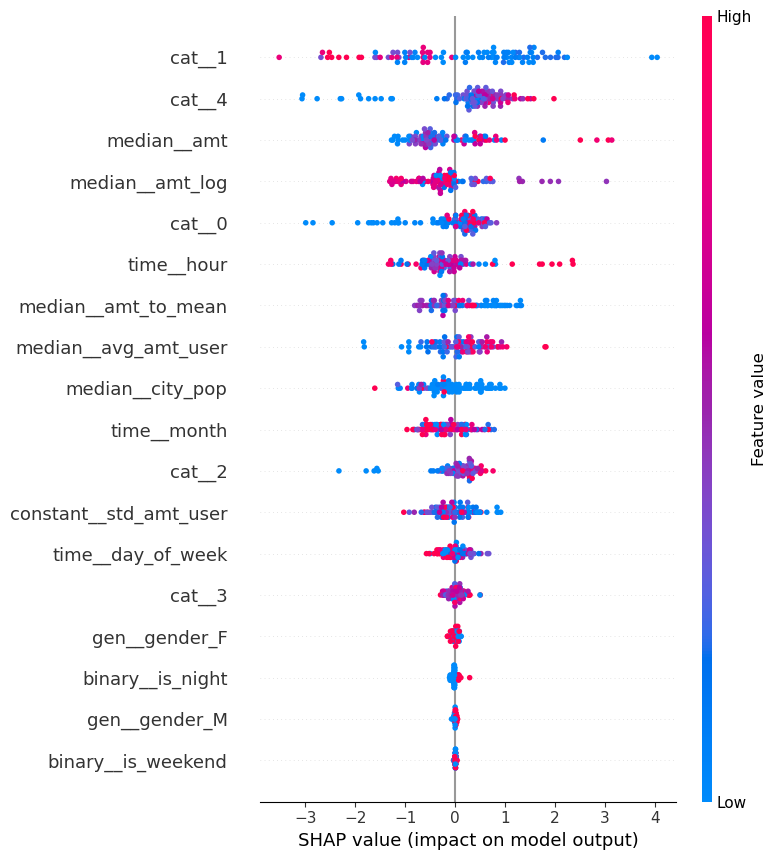

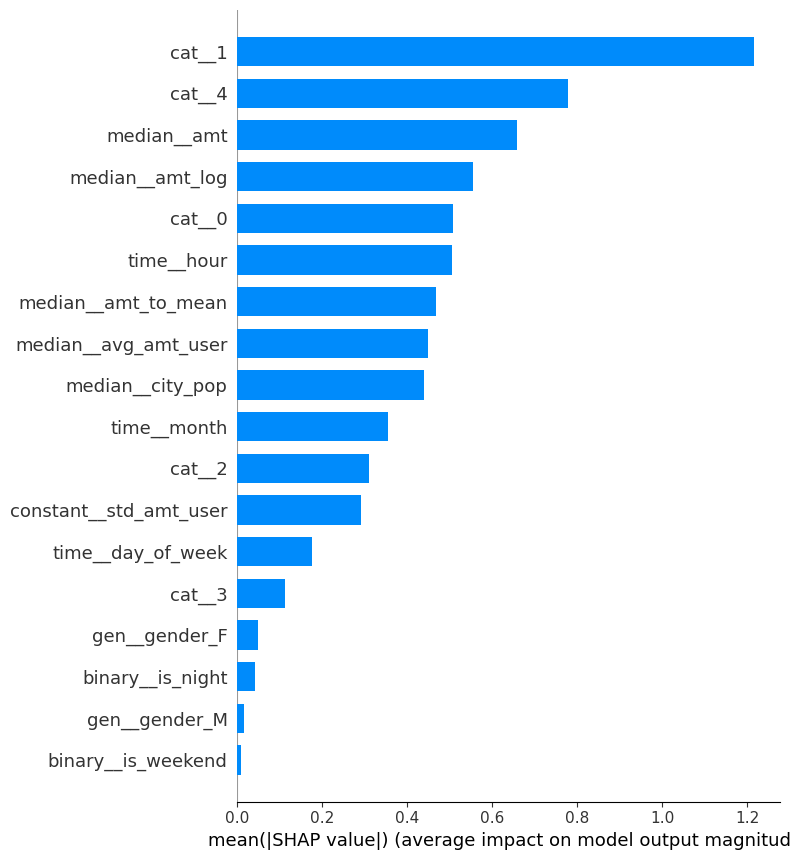

<function matplotlib.pyplot.show(close=None, block=None)>

In [29]:
pipe_no_smote = Pipeline([
    ('preprocessor', preprocessor),
    ('model', models[base_model_name])
])
pipe_no_smote.fit(X_train, y_train)
X_sample_raw = X_test.sample(100, random_state=42)
X_sample = pipe_no_smote.named_steps['preprocessor'].transform(X_sample_raw)
if hasattr(X_sample, "toarray"):
    X_sample = X_sample.toarray()
X_sample = X_sample.astype(float)
try:
    feature_names = (pipe_no_smote.named_steps['preprocessor'].get_feature_names_out())
except:
    feature_names = None
explainer = shap.TreeExplainer(pipe_no_smote.named_steps['model'],feature_perturbation="interventional")
shap_values = explainer.shap_values(X_sample, check_additivity=False)
if isinstance(shap_values, list):
    shap_values = shap_values[1]
shap.summary_plot(shap_values, X_sample, feature_names = feature_names, max_display=20)
plt.show()
shap.summary_plot(shap_values,X_sample,feature_names=feature_names,plot_type="bar",max_display=20)
plt.show

In [32]:
if best_name in ["RF", "XGB", "LGBM"]:
    pipeline_key = best_name + "_SMOTE"
else:
    pipeline_key = best_name

final_pipeline = trained_pipelines[pipeline_key]

print("\nFINAL PIPELINE READY")

print("Best Model:", pipeline_key)


FINAL PIPELINE READY
Best Model: LGBM_SMOTE


In [34]:
print(trained_pipelines)

{'RF_NO_SMOTE': Pipeline(steps=[('preprocessor',
                 ColumnTransformer(sparse_threshold=0,
                                   transformers=[('median',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['amt', 'amt_log',
                                                   'avg_amt_user',
                                                   'amt_to_mean', 'city_pop']),
                                                 ('constant',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value=0,
                                        

In [35]:
path = r"../Model/"
os.makedirs(path,exist_ok=True)
joblib.dump(final_pipeline,path + "fraud_detection_pipeline.pkl")
joblib.dump(final_threshold,path + "best_threshold.pkl")
feature_names = (final_pipeline.named_steps['preprocessor'].get_feature_names_out())
joblib.dump(feature_names,path + "feature_names.pkl")
best_ann = ann_no
best_ann.save(path + "ann_model.keras")
ensemble_config = {"ml_weight": 0.7,"ann_weight": 0.3,"best_ensemble": best_ensemble}
joblib.dump(ensemble_config,path + "ensemble_config.pkl")
print("\nALL MODELS SAVED SUCCESSFULLY")


ALL MODELS SAVED SUCCESSFULLY
